# 安全 PII 去識別化 & RAG 檢索 🥷🏽 (逐步拆解展示版)
---
這份 Notebook 是在 **Docker 獨立環境內執行** 的，它已經自動準備好了完整的工具鏈！
我們將**一步一步**帶你透視整個魔法是怎麼發生的，從「單筆資料如何隱藏個資」，到「LLM 回覆後如何還原」。

In [1]:
import os
from pprint import pprint
from dotenv import load_dotenv
load_dotenv() # 載入 API Keys 與 Database 設定

True

### 🟢 Step 1: 單筆資料的去識別化 (Privacy Encoder)
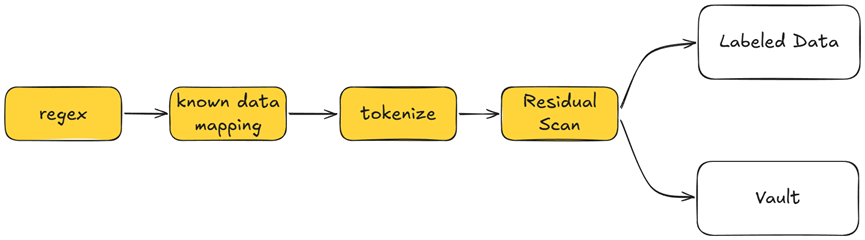<br>
讓我們先取一筆假資料，呼叫 `PrivacyEncoder` 看看它吐出來的**匿名文本**加上被抽離出來的 **Vault 對照表**長怎樣。

In [2]:
from src.encoder import PrivacyEncoder

encoder = PrivacyEncoder(use_presidio=False)

# 模擬一筆 CSV 進來的投訴紀錄
fake_record = {
    "name": "林大明",
    "phone": "0912-345-678",
    "address": "台北市信義區信義路五段7號",
    "credit_card": "1234-5678-1234-5678",
    "category": "客服態度",
    "complaint_text": "我是林大明，我的信用卡 1234-5678-1234-5678 說被盜刷，電話 0912-345-678 也打不通，我住在台北市信義區信義路五段7號，你們客服真的很爛！"
}

encoded_result = encoder.encode_record(fake_record)

print("【原始資料】", encoded_result.original_text)
print("【去識別化後】", encoded_result.encoded_text)
print("【PII Vault】", encoded_result.vault_snapshot)

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Encoder] 雙次掃描模式（Presidio=已停用）
【原始資料】 我是林大明，我的信用卡 1234-5678-1234-5678 說被盜刷，電話 0912-345-678 也打不通，我住在台北市信義區信義路五段7號，你們客服真的很爛！
【去識別化後】 我是[PERSON_1]，我的信用卡 [CREDIT_CARD_1] 說被盜刷，電話 [PHONE_1] 也打不通，我住在[ADDRESS_1]，你們客服真的很爛！
【PII Vault】 {'[PERSON_1]': '林大明', '[CREDIT_CARD_1]': '1234-5678-1234-5678', '[PHONE_1]': '0912-345-678', '[ADDRESS_1]': '台北市信義區信義路五段7號'}


### 🟢 Step 2: 完整入庫 (執行 Pipeline)
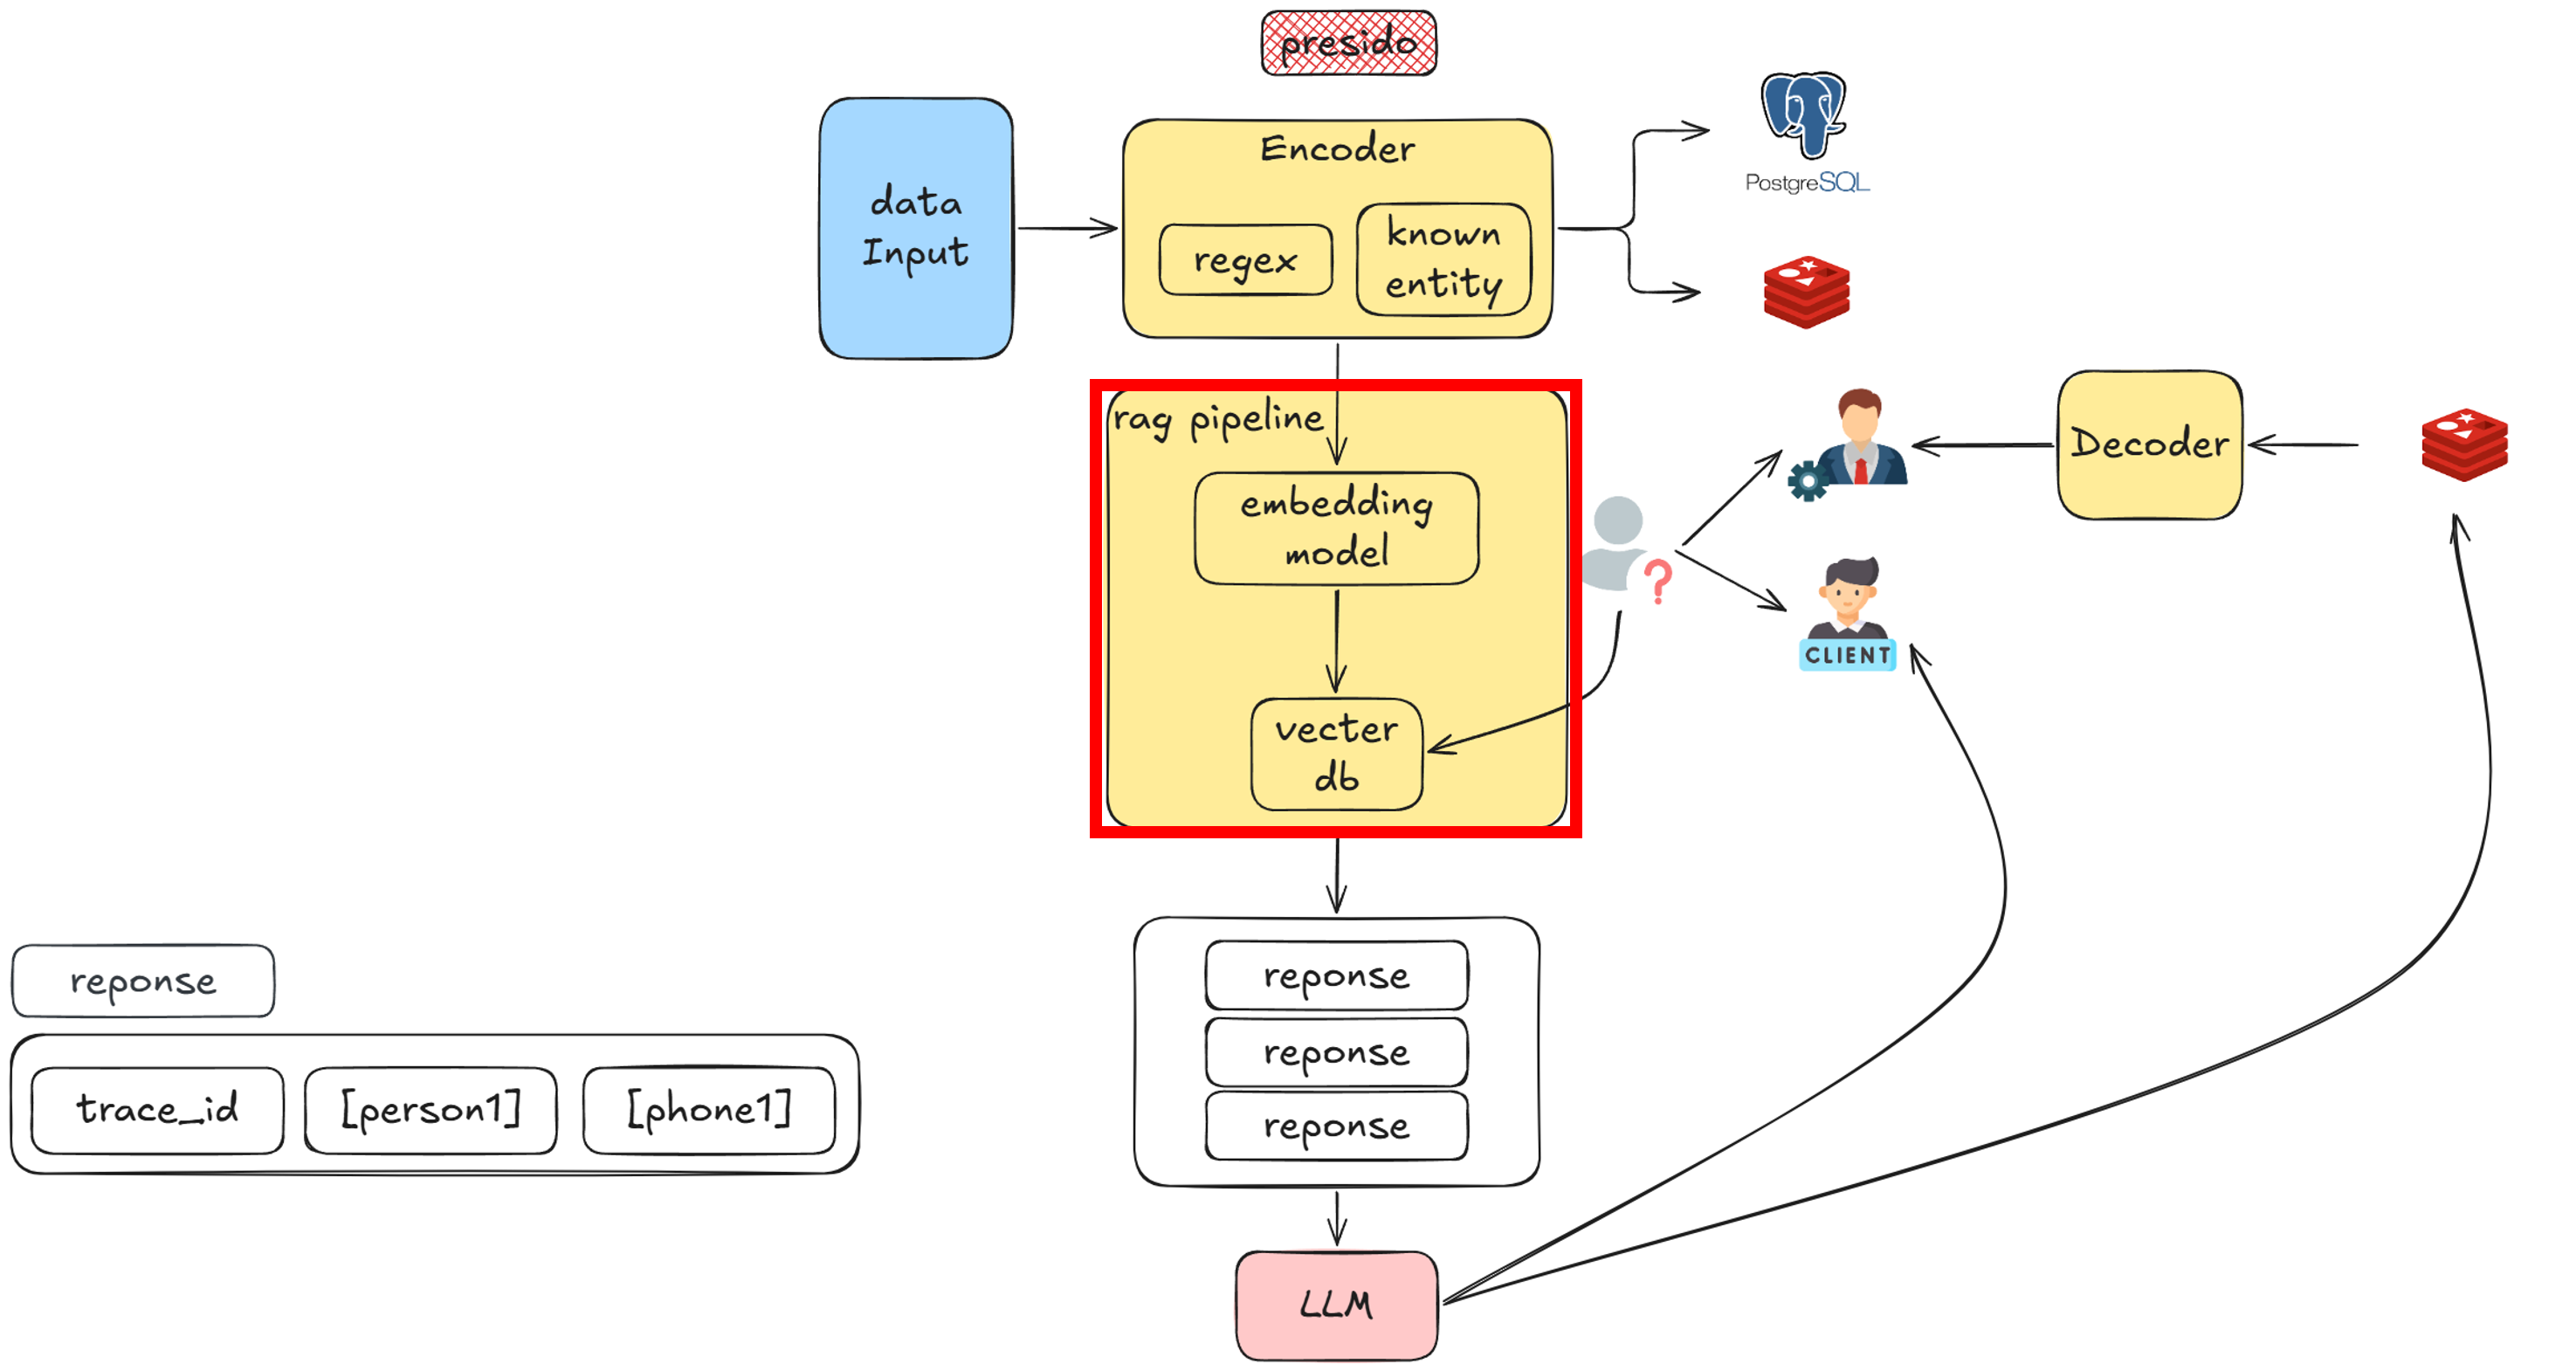
現在你看到它的樣子了，我們把 `data/個資範例資料.csv` 裡面的 100 筆資料全部轉成這個樣子。
這個指令會：做 Encoder -> 算好 768 維的 Embedding Vector -> 存進 PostgreSQL 與 Redis。

In [3]:
from src.pipeline import run_pipeline
from src.db import get_row_counts

print("開始執行 Pipeline 入庫... (約需 10 秒算 100 筆向量)")
run_pipeline(verbose=False)
print("\n✅ 最新各表狀態：", get_row_counts())

開始執行 Pipeline 入庫... (約需 10 秒算 100 筆向量)
[Pipeline] 檢查 PostgreSQL 連線 ...
[Pipeline] ✅ PostgreSQL 連線正常
[Pipeline] 讀取 100 筆資料
[Encoder] 雙次掃描模式（Presidio=已停用）
[Pipeline] Encode + 入庫完成 (1.5s)
[Pipeline] 開始批次 Embedding 與存入 PGVector (100 筆) ...
[Embedding] 載入模型 BAAI/bge-base-zh-v1.5 ...


Loading weights: 100% 199/199 [00:00<00:00, 14780.71it/s]
/app/src/embedding.py:23: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"[Embedding] 模型就緒 (dim={_model.get_sentence_embedding_dimension()})")


[Embedding] 模型就緒 (dim=768)
[Pipeline] 向量入庫完成 (7.5s)

[Pipeline] ✅ 全部完成！耗時 9.0s
[Pipeline] 各表行數: {'customers': 100, 'pii_vault': 285, 'langchain_pg_collection': 1, 'langchain_pg_embedding': 100, 'complaint_summaries': 0}

✅ 最新各表狀態： {'customers': 100, 'pii_vault': 285, 'langchain_pg_collection': 1, 'langchain_pg_embedding': 100, 'complaint_summaries': 0}


### 🟢 Step 3: 向量語義檢索 (Vector Search)
當下達 Query 時，我們將 Query 做 Embedding 並送給 pgvector 找出前 n 筆最相似的原文。

In [4]:
from src.embedding import embed_query
from src.rag import retrieve

user_query = "哪些客戶反映了重複扣款的問題？聽說有人的信用卡扣了兩次？"

print(f"🔍 提問: {user_query}\n")
results = retrieve(user_query, top_k=2)

for r in results:
    print(f"👉 [相似度 {r['similarity']:.3f} | 案件 {r['trace_id']}] \n{r['encoded_text']}\n")

🔍 提問: 哪些客戶反映了重複扣款的問題？聽說有人的信用卡扣了兩次？

👉 [相似度 0.666 | 案件 TRACE_e46d] 
[PERSON_1]在此，我刷了[CREDIT_CARD_1]這張卡要買東西，結果重複扣款兩次，電話[PHONE_1]。

👉 [相似度 0.610 | 案件 TRACE_4115] 
我是[PERSON_1]，[ADDRESS_1]的帳單卡號 [CREDIT_CARD_1] 重複扣款。



### 🟢 Step 4: 跨 Trace 個資打架防撞機制 (Re-tag)
💡 **超級核心技術痛點**：兩筆找出來的結果可能都有 `[PERSON_1]` 但指代的人完全不同！
所以我們要為他們建立獨一無二的身分證字號（透過加 `@xxx` 後綴）。

In [5]:
from src.decoder import retag_text, build_merged_vault
import re

# 讓我們幫前面找到的 2 筆文本做 Re-tag
trace_ids = [r['trace_id'] for r in results]
context_parts = []

for r in results:
    old_text = r['encoded_text']
    new_text = retag_text(old_text, r['trace_id'])
    print(f"💥【轉換前】 {old_text[:60]}...")
    print(f"✨【轉換後】 {new_text[:60]}...\n")
    context_parts.append(f"[案件 {r['trace_id']}] {new_text}")

final_context = "\n\n".join(context_parts)
merged_vault = build_merged_vault(trace_ids)

print("\n📁【這是我們準備發給 LLM 解析的總合 Vault 金庫 (Merged Vault)】:")
pprint(merged_vault)

💥【轉換前】 [PERSON_1]在此，我刷了[CREDIT_CARD_1]這張卡要買東西，結果重複扣款兩次，電話[PHONE_1]。...
✨【轉換後】 [PERSON_1@e46d]在此，我刷了[CREDIT_CARD_1@e46d]這張卡要買東西，結果重複扣款兩次，電話...

💥【轉換前】 我是[PERSON_1]，[ADDRESS_1]的帳單卡號 [CREDIT_CARD_1] 重複扣款。...
✨【轉換後】 我是[PERSON_1@4115]，[ADDRESS_1@4115]的帳單卡號 [CREDIT_CARD_1@4115]...


📁【這是我們準備發給 LLM 解析的總合 Vault 金庫 (Merged Vault)】:
{'[ADDRESS_1@4115]': '台南市安平區平通路',
 '[CREDIT_CARD_1@4115]': '5408-2222-3333-4444',
 '[CREDIT_CARD_1@e46d]': '4321-8765-4321-1098',
 '[PERSON_1@4115]': '賴清德',
 '[PERSON_1@e46d]': '黃國華',
 '[PHONE_1@e46d]': '0910111222'}


### 🟢 Step 5: 傳送給 LLM Fallback (並要求保留 Tag)

In [6]:
from src.rag import RAG_PROMPT_TEMPLATE
from src.llm import call_llm

prompt = RAG_PROMPT_TEMPLATE.format(context=final_context, query=user_query)

print("呼叫 LLM... (如果 Gemini 爆 Quota 將自動Fallback切至 OpenAI gpt-4o-mini)\n")
encoded_answer, model_used = call_llm(prompt, verbose=True)

print("\n=================== 🤖 LLM 原生回答 ===================")
print(encoded_answer)

呼叫 LLM... (如果 Gemini 爆 Quota 將自動Fallback切至 OpenAI gpt-4o-mini)

[LLM] 嘗試 Gemini Key 1 (AIzaSyCK...RzP8)...


/app/src/llm.py:32: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


[LLM] ⚠️  Gemini Key 1 額度耗盡，切換下一個...
[LLM] 嘗試 Gemini Key 2 (AIzaSyAG...2gao)...
[LLM] ⚠️  Gemini Key 2 額度耗盡，切換下一個...
[LLM] 嘗試 OpenAI (gpt-4o-mini)...
[LLM] ✅ OpenAI gpt-4o-mini 成功

=================== 🤖 LLM 原生回答 ===================
根據檢索到的投訴記錄，以下客戶反映了重複扣款的問題：

1. [PERSON_1@e46d] 在案件 [TRACE_e46d] 中提到，他使用了[CREDIT_CARD_1@e46d]進行購物，結果重複扣款兩次。
2. [PERSON_1@4115] 在案件 [TRACE_4115] 中也提到，其帳單卡號 [CREDIT_CARD_1@4115] 發生了重複扣款。

因此，確實有客戶的信用卡被扣款兩次。


### 🟢 Step 6: 終極還原！呼叫 Decoder
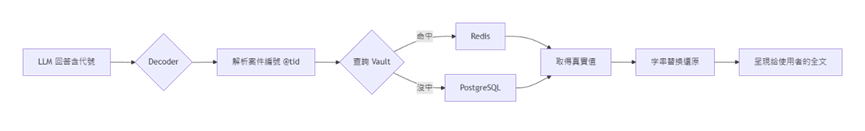<br>

拿 LLM 的回復去比對前面準備好的 `merged_vault` 字典做還原！

In [7]:
from src.decoder import PrivacyDecoder

decoder = PrivacyDecoder()

# 我們順便作一下 Tag Hallucination 驗證（防幻覺）
tag_check = decoder.validate_tags(final_context, encoded_answer)
print(f"✅ 無幻覺檢查：{tag_check}\n")

decoded_answer = decoder.decode_rag(encoded_answer, merged_vault)

print("=================== 🎉 給客戶端的無瑕疵還原最終答案 ===================")
print(decoded_answer)

✅ 無幻覺檢查：{'valid': False, 'missing': {'[ADDRESS_1@4115]', '[PHONE_1@e46d]'}, 'extra': {'[TRACE_4115]'}}

=================== 🎉 給客戶端的無瑕疵還原最終答案 ===================
根據檢索到的投訴記錄，以下客戶反映了重複扣款的問題：

1. 黃國華 在案件 [TRACE_e46d] 中提到，他使用了4321-8765-4321-1098進行購物，結果重複扣款兩次。
2. 賴清德 在案件 [TRACE_4115] 中也提到，其帳單卡號 5408-2222-3333-4444 發生了重複扣款。

因此，確實有客戶的信用卡被扣款兩次。


### 🟢 Step 7: 權限切換測試 (Guest 模式)
這是一個加碼展示！如果我們在環境變數切換成 Guest 權限，讓我們看看剛剛相同的 RAG 流程會有什麼不同的結果（Guest 不會經過 Decoder 還原，且 Prompt 會要求通用總結）。

In [8]:
import os
from src.rag import RAG_GUEST_PROMPT_TEMPLATE

# 暫時將環境變數切換為 Guest
os.environ["USER_ROLE"] = "guest"

print("【切換為 Guest 權限】\n")
prompt_guest = RAG_GUEST_PROMPT_TEMPLATE.format(context=final_context, query=user_query)

print("呼叫 LLM (Guest 模式)...\n")
guest_answer, model_used = call_llm(prompt_guest, verbose=True)

print("\n=================== 🤖 LLM 原生回答 (Guest) ===================")
print(guest_answer)

# 註: Guest 模式不經過 Decoder，直接將 LLM 回答呈現給前端！
print("\n(沒有 Decoder 還原，直接輸出安全無特徵的總結！)")

# 復原回 admin
os.environ["USER_ROLE"] = "admin"

【切換為 Guest 權限】

呼叫 LLM (Guest 模式)...

[LLM] 嘗試 Gemini Key 1 (AIzaSyCK...RzP8)...
[LLM] ⚠️  Gemini Key 1 額度耗盡，切換下一個...
[LLM] 嘗試 Gemini Key 2 (AIzaSyAG...2gao)...
[LLM] ⚠️  Gemini Key 2 額度耗盡，切換下一個...
[LLM] 嘗試 OpenAI (gpt-4o-mini)...
[LLM] ✅ OpenAI gpt-4o-mini 成功

=================== 🤖 LLM 原生回答 (Guest) ===================
根據檢索到的投訴記錄，有兩位客戶反映了重複扣款的問題。第一位客戶在使用某張信用卡購物時，發現該卡被重複扣款兩次。第二位客戶也表示其帳單卡同樣出現了重複扣款的情況。這些投訴顯示出在支付過程中可能存在系統或處理上的問題。

(沒有 Decoder 還原，直接輸出安全無特徵的總結！)
